# **Реализация метода KMeans**

Для начала необходимо реализовать функцию для вычисления расстояния между точками в пространстве.

Для этого буду использовать 3 метрики:

Евклидово расстояние (Euclid)  
Измеряет расстояние между точками по прямой линии.
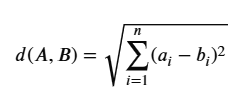

Манхэттенское расстояние (Manhattan)

Измеряет расстояние, если двигаться только по сетке (как по улицам Манхэттена).
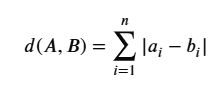

Расстояние Чебышёва (Max)

Находит максимальное различие среди всех осей координат.
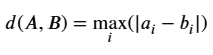

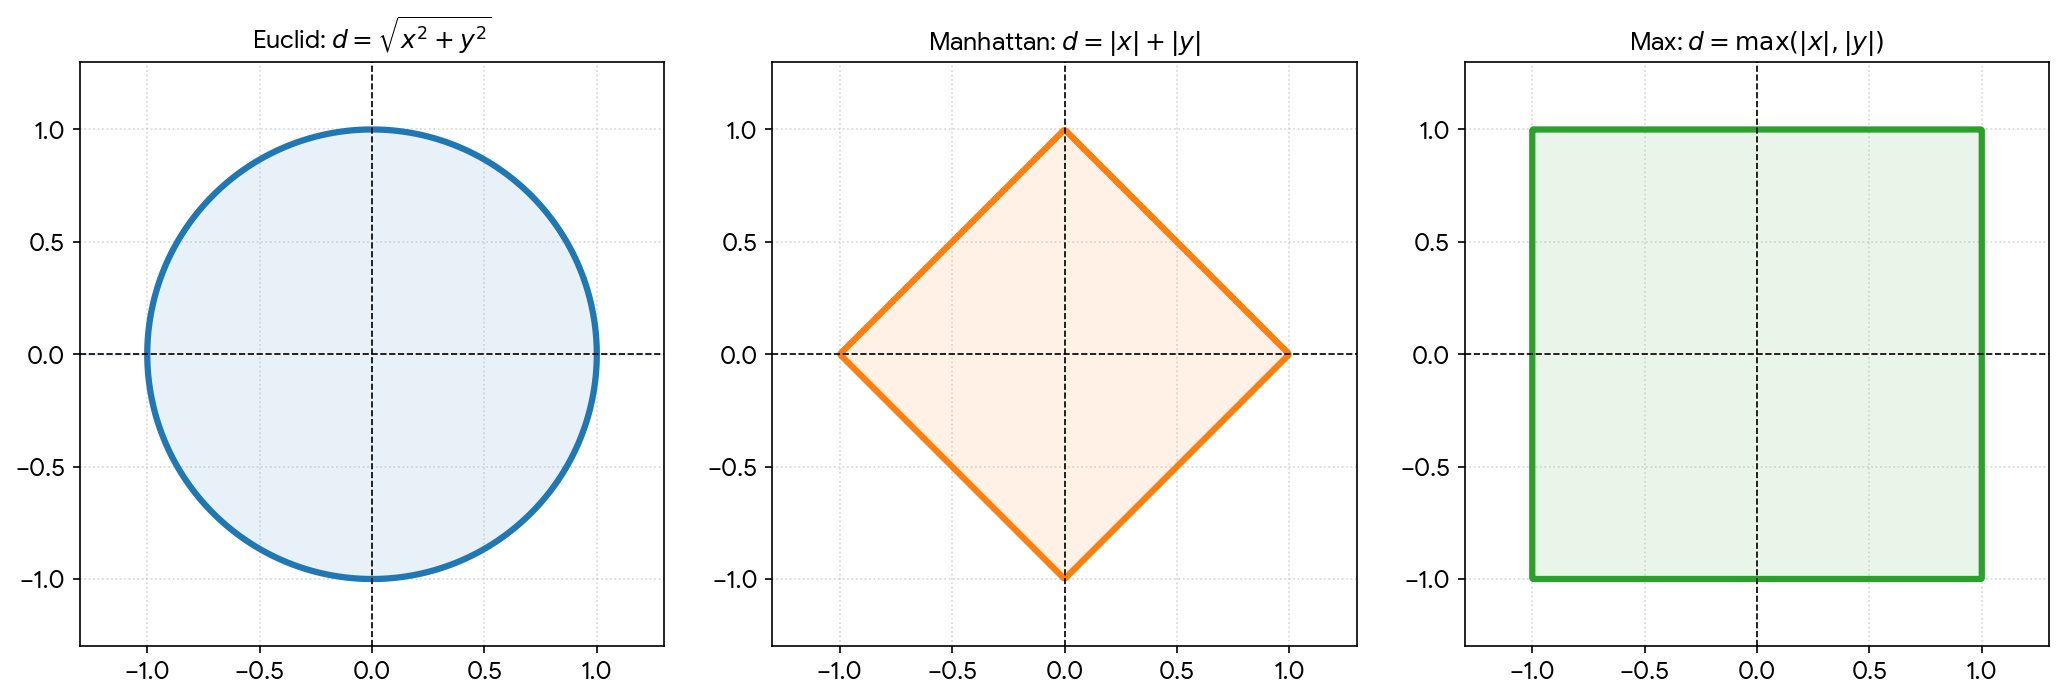

### Доступные метрики и их геометрия на плоскости

* **Euclid (Евклидово) — Идеальный круг:**
  Расстояние по прямой линии. Все точки на расстоянии $1$ от центра образуют привычную нам круглую геометрическую окружность.

* **Manhattan (Манхэттенское) — Повернутый квадрат (Ромб):**
  Движение разрешено только строго по горизонтали и вертикали. Из-за этого «окружность» радиуса $1$ превращается в ромб с вершинами на координатных осях $(1,0)$, $(0,1)$, $(-1,0)$, $(0,-1)$.

* **Max / Chebyshev (Максимальное) — Прямой квадрат:**
  Считается только наибольшее отклонение по одной из осей. Точка $(1, 1)$ имеет расстояние $1$, точка $(1, 0.5)$ — тоже расстояние $1$. В результате получается квадрат со сторонами, параллельными осям координат.


In [130]:
import pandas as pd
import numpy as np


df = pd.DataFrame({'p1':[3,5,4,5],'p2':[4,5,3,4],'p3':[5,5,3,3],'p4':[3,4,2,3],'p':[4,3,5,None]}, index = ['A1','A2','A3','A'])

df

,p1,p2,p3,p4,p
A1,3,4,5,3,4.0
A2,5,5,5,4,3.0
A3,4,3,3,2,5.0
A,5,4,3,3,NaN


Данный метод можно использовать как способ заполнений данных
#### Как геометрия метрик влияет на восстановление данных?

При поиске ближайших соседей (близких строк/точек для заполнения пропусков):
* **Евклид** ищет соседей в равной степени по всем направлениям (радиально).
* **Манхэттен** жестко штрафует за одновременное отклонение по нескольким признакам (стягивает область поиска к осям координат).
* **Max** игнорирует мелкие различия в сопутствующих признаках, если по какому-то одному признаку различие уже достигло максимума (расширяет область поиска до углов квадрата).


In [131]:
def get_distance(point1,point2, metric = 'Euclid'):
  """
Вычисляет расстояние между двумя точками.

Доступные метрики:
- 'Euclid': корень из суммы квадратов разностей координат.
- 'Manhattan': сумма модулей координат.
- 'Max': максимальный модуль разности среди всех координат.

Аргументы:
- point1 (list, np.ndarray): Координаты первой точки.
- point2 (list, np.ndarray): Координаты второй точки.
- metric (str): Название метрики ('Euclid', 'Manhattan', 'Max').

Возвращает:
- float: Значение расстояния между точками.
- None: Если размерности точек не совпадают.

Пример использования с Pandas:
>>> p_A = df.loc['A', :'p4'].values
>>> p_A1 = df.loc['A1', :'p4'].values
>>> get_distance(p_A, p_A1, metric='Max')
"""

  if len(point1) != len(point2):
    return None
  res = 0

  for i in range(len(point1)):
    if metric == 'Euclid':
        res += (point1[i] - point2[i]) ** 2
    elif metric == 'Manhattan':
        res += abs(point1[i] - point2[i])
    elif metric == 'Max':
        res = -10**10
        res = max(res,abs(point1[i] - point2[i]))

  if metric == 'Euclid':
    return res**0.5
  return res

In [132]:
print(get_distance(df.loc['A',:].values[:-1],df.loc['A1',:].values[:-1]))

2.8284271247461903


Это значение можно использовать для заполнения пропуска в данных

In [133]:
print(get_distance.__doc__)


Вычисляет расстояние между двумя точками.

Доступные метрики:
- 'Euclid': корень из суммы квадратов разностей координат.
- 'Manhattan': сумма модулей координат.
- 'Max': максимальный модуль разности среди всех координат.

Аргументы:
- point1 (list, np.ndarray): Координаты первой точки.
- point2 (list, np.ndarray): Координаты второй точки.
- metric (str): Название метрики ('Euclid', 'Manhattan', 'Max').

Возвращает:
- float: Значение расстояния между точками.
- None: Если размерности точек не совпадают.

Пример использования с Pandas:
>>> p_A = df.loc['A', :'p4'].values
>>> p_A1 = df.loc['A1', :'p4'].values
>>> get_distance(p_A, p_A1, metric='Max')



### Реализация класса Kmeans с поддержской 3-х метрик.

1. Иницилизировать класс **KMeans** параметрами ($K$, max_iter`, metric)
2. Использовать **get_distance** для рассчета матрицы расстояний между точками и центроидами по одной из трех формул (*Euclid, Manhattan, Max*).
3. В **fit** случайно выбрать $K$ уникальных строк из датасета в качестве стартовых центроидов.
4. В цикле до **max_iter** привязывать точки к ближайшим центрам, обновлять координаты центров через **np.mean** и выходить при их стабилизации.
5. **predict**: Вычислять расстояния от новых точек до финальных центроидов и возвращать индексы их кластеров.


In [134]:
import pandas as pd
import numpy as np

class Kmeans():
    def __init__(self, K=2, max_iter = 100, metric = 'Euclid'):
        self.K = K
        self.max_iter = max_iter
        self.metric = metric


    def get_distance(self,X,centroids):
        """
        Вычисляет попарные расстояния между всеми точками данных и всеми центроидами.

        Использует метрику, указанную при инициализации класса (self.metric).

        Аргументы:
        ----------
        X : np.ndarray
            Двумерный массив (матрица) точек данных размера (N, D),
            где N — количество объектов, а D — размерность пространства (число признаков).
        centroids : np.ndarray
            Двумерный массив (матрица) текущих координат центроидов размера (K, D),
            где K — количество кластеров, а D — размерность пространства.

        Возвращает:
        -----------
        np.ndarray (размера N x K)
            Матрица расстояний, где элемент в строке i и столбце j равен
            расстоянию между i-й точкой данных и j-м центроидом.
        None
            Если размерности пространств (количество столбцов) у X и centroids не совпадают.

        Доступные метрики:
        ----------------------------------
        - 'Euclid'            : Корень из суммы квадратов разностей координат (L2-норма).
        - 'Manhattan', 'Manh' : Сумма модулей разностей координат (L1-норма, расстояние городских кварталов).
        - 'Max', 'Chebyshev'  : Максимальный модуль разности среди всех координат (Расстояние Чебышёва).
        """
        X = np.asarray(X)

        if X.shape[1] != centroids.shape[1]:
          raise ValueError("Количество признаков у X и центроидов должно совпадать.")

        res = np.zeros((X.shape[0], centroids.shape[0]))


        for i in range(X.shape[0]):
            for j in range(centroids.shape[0]):
                diff = X[i] - centroids[j]
                if self.metric == 'Euclid':
                    res[i][j] = np.sum(diff ** 2)
                elif self.metric in ['Manhattan','Manh']:
                    res[i][j] = np.sum(np.abs(diff))
                elif self.metric in ['Max','Chebyshev']:
                    res[i][j] = np.max(np.abs(diff))
                else:
                    raise ValueError(f'Неизвестная метрика - {self.metric}')

        if self.metric == 'Euclid':
          return res**0.5
        return res

    def fit(self,X):
        X = np.asarray(X)

        random_indices = np.random.choice(len(X), size=self.K, replace=False)
        centroids = X[random_indices]

        for epoch in range(1,self.max_iter+1):
            old_centr = centroids.copy()

            distances = self.get_distance(X, centroids)
            closest_clusters = np.argmin(distances, axis=1)  # argmin - индексы ближайших центроидов для каждой точки

            for k in range(self.K):  # Пересчет координат центроидов
                cluster_points = X[closest_clusters == k]

                if len(cluster_points) > 0:
                    centroids[k] = np.mean(cluster_points, axis=0)  # Помещает центроид в серидину k кластера.

            if np.all(old_centr == centroids):  # Стабилизации центроидов.
                break

        self.centroids = centroids  # Атрибут для центров
        self.labels = closest_clusters  # Метка кластера
        self.epoch = epoch

        return centroids

    def predict(self, X_new):
        distances = self.get_distance(X_new, self.centroids)
        return np.argmin(distances, axis = 1)





In [135]:
np.random.seed(42)
center = [0,0]
std = .75

X = np.random.normal(loc=center, scale=std, size=(30, 2))

KM = Kmeans(K = 2)
KM.fit(X)

new_objects = np.array([
    [-1.5, 0.5],
    [2.0, 1.25]
])

new_labels = KM.predict(new_objects)
print(f'Точка по координатам {new_objects[0]} принадлежит кластеру {new_labels[0]}, вторая точка {new_objects[1]} принадлежит класстеру {new_labels[1]}')


Точка по координатам [-1.5  0.5] принадлежит кластеру 0, вторая точка [2.   1.25] принадлежит класстеру 1


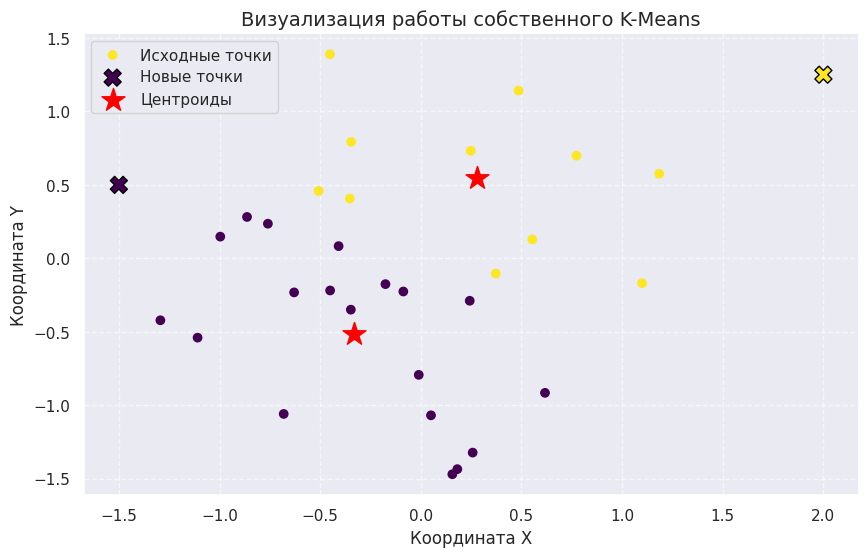

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X[:, 0], X[:, 1], c=KM.labels, cmap='viridis',marker='o', label='Исходные точки')

new_labels = KM.predict(new_objects)
plt.scatter(new_objects[:, 0], new_objects[:, 1], c=new_labels, cmap='viridis', s=150, marker='X', edgecolors='black', label='Новые точки')


plt.scatter(KM.centroids[:, 0], KM.centroids[:, 1], c='red', s=300, marker='*', label='Центроиды')


plt.title('Визуализация работы собственного K-Means', fontsize=14)
plt.xlabel('Координата X', fontsize=12)
plt.ylabel('Координата Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

In [137]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt  # Добавлен импорт
import pandas as pd
import numpy as np
import seaborn as sns


def draw(metric, X, y_true):
    np.random.seed(42)

    KM_large = Kmeans(K=3, max_iter=20, metric=metric)
    new = KM_large.fit(X)

    df_large = pd.DataFrame(X, columns=["Признак 1", "Признак 2"])
    df_large["Кластер"] = KM_large.labels

    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df_large,
        x="Признак 1",
        y="Признак 2",
        hue="Кластер",
        palette="Set2",  # Пастельная палитра
        alpha=0.8,  # Прозрачность
        s=60,
    )

    plt.scatter(
        KM_large.centroids[:, 0],
        KM_large.centroids[:, 1],
        color="red",
        s=250,
        marker="*",
        edgecolors="black",
        linewidth=1.5,
        label="Центроиды",
    )

    # Оформление
    plt.title(
        f"Кластеризация 500 точек собственным алгоритмом K-Means метрикой {metric}",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.legend()
    plt.show()


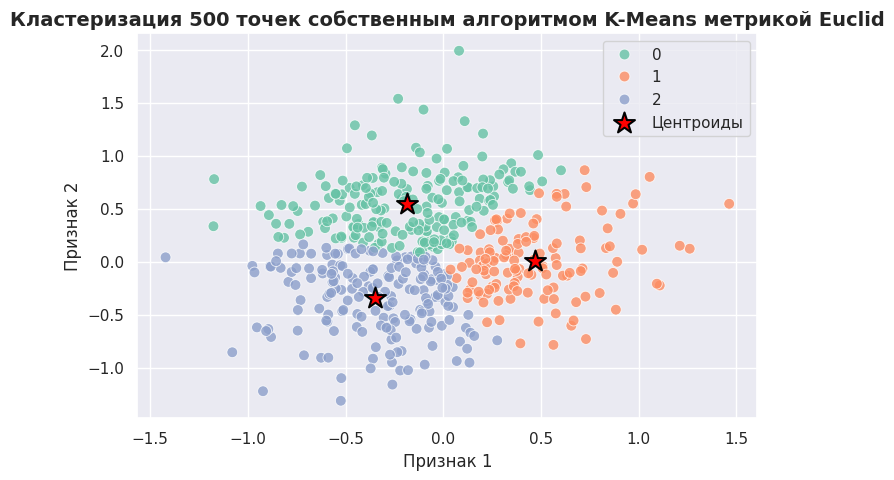

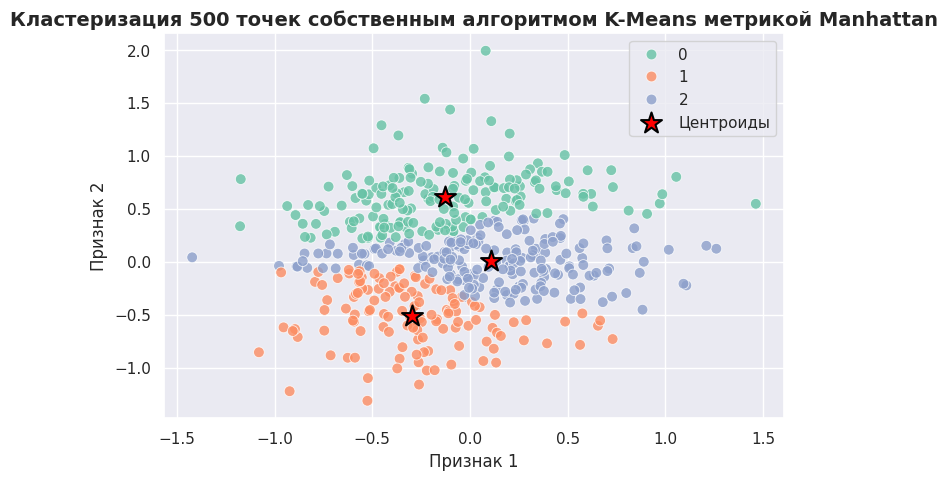

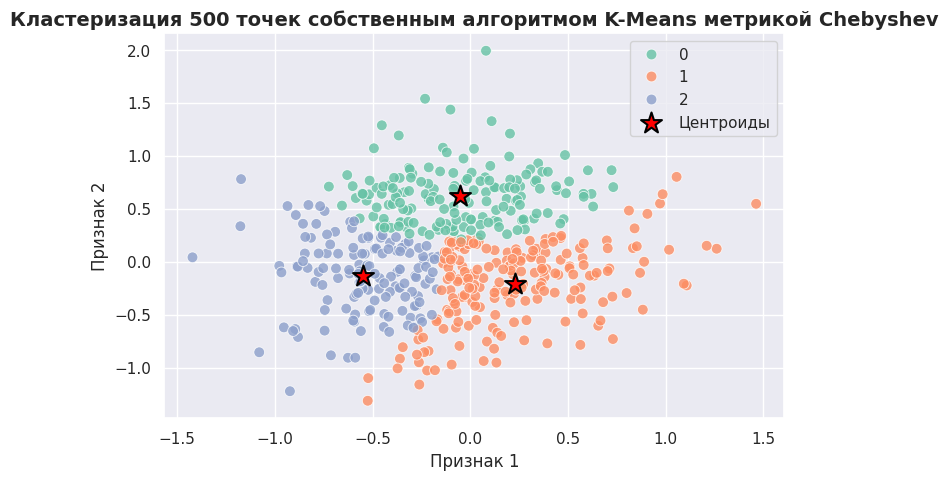

In [138]:
X, y = make_blobs(
        n_samples=500,
        n_features=2,
        centers=3,
        cluster_std=0.4,
        random_state=42,
        center_box=(-0.5, 0.5),
    )

for metric in ['Euclid','Manhattan','Chebyshev']:
    draw(metric, X, y)

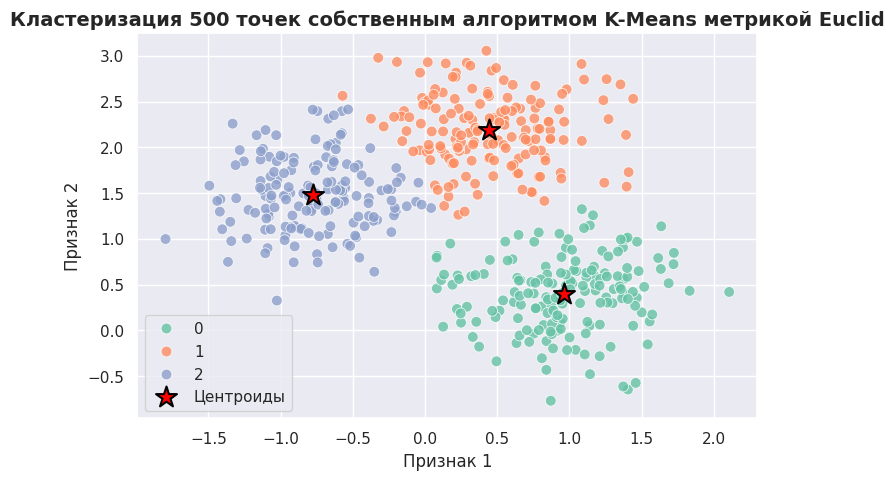

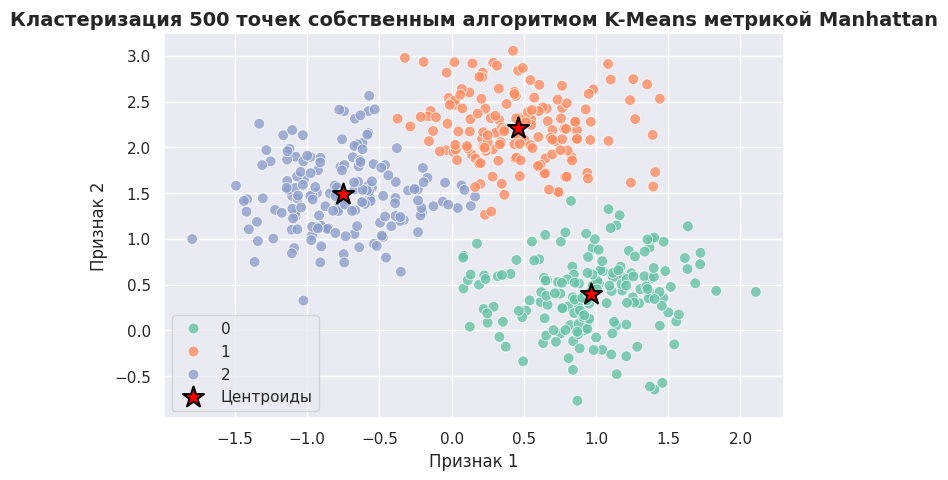

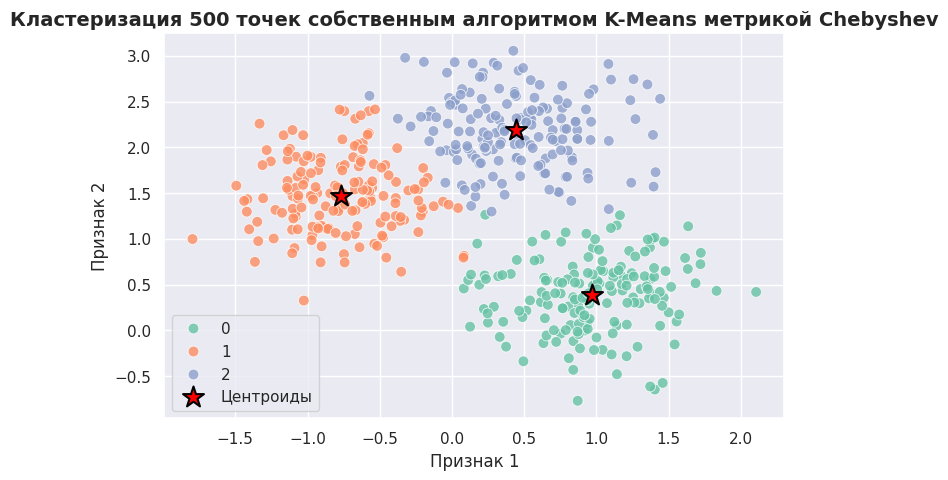

In [139]:
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=3,
    cluster_std=0.4,
    random_state=0,
    center_box=(-5.0, 5.0),
)

for metric in ['Euclid','Manhattan','Chebyshev']:
    draw(metric, X, y)

###  Важное ограничение алгоритма K-Means

Используем алгоритм на **геометрически сложных данных** (в данном случае — на двух вложенных кольцах).

У классического алгоритма K-Means есть фундаментальная слабость: он разработан для поиска **выпуклых, округлых (сферических) сгустков** данных примерно одинакового размера. Алгоритм группирует точки исключительно по принципу «какой центр ближе», абсолютно ничего не зная про форму, линии или непрерывность объектов.

1. **Разрез вместо разделения:** На графике заметно, что ни одна метрика не сможет отделить внутреннее кольцо от внешнего. Вместо этого K-Means просто разрезает «мишень» пополам, объединив в один кластер половину внутреннего и половину внешнего кольца.
2. **Форма границы раздела:** Все три метрики одинаково плохо определяют линию разреза между кластерами:
   * **Euclid** проводит идеальную прямую линию.
   * **Manhattan** и **Chebyshev** из-за своей формулы модулей разделят пространство ломаными, угловатыми линиями.

*Этот эксперимент наглядно доказывает: для данных со сложной геометрией K-Means не подходит. В таких задачах на практике используют другие алгоритмы (например, DBSCAN).*


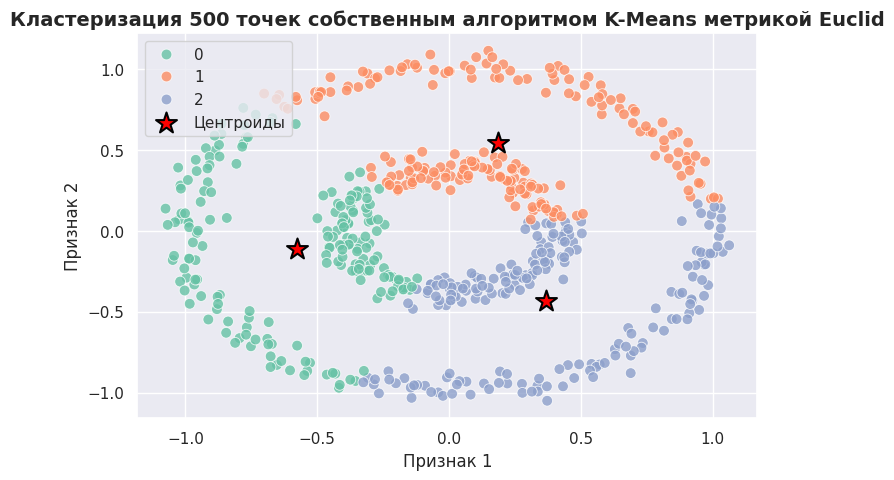

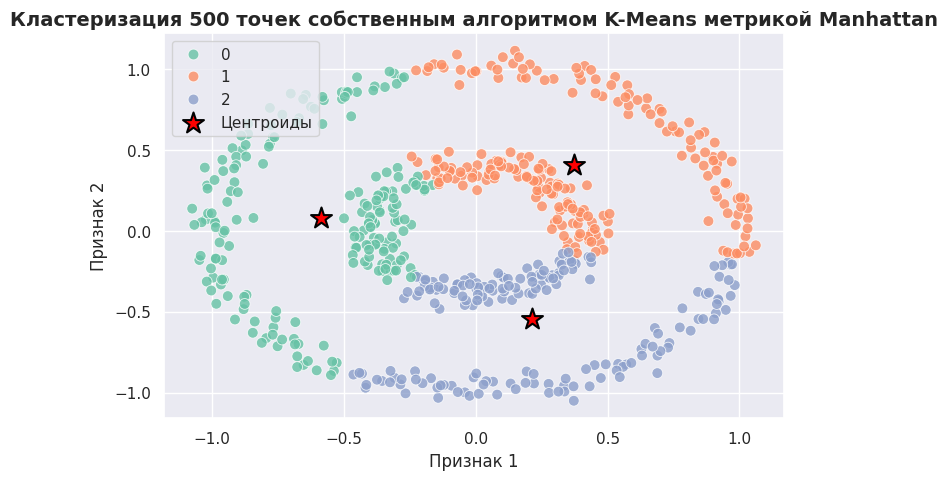

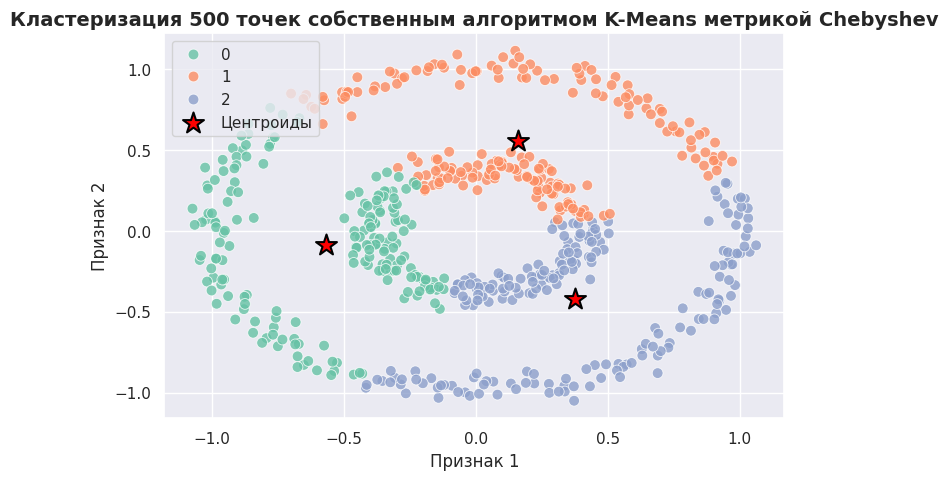

In [140]:
from sklearn.datasets import make_circles
X, y = make_circles(
    n_samples=600,
    factor=0.4,       # Расстояние между внутренним и внешним кольцом
    noise=0.05,       # Уровень случайного шума
    random_state=42
)

for metric in ['Euclid','Manhattan','Chebyshev']:
    draw(metric, X, y)